In [8]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import PDBParser, Superimposer
from Bio.PDB.Polypeptide import is_aa

# ver useful doumentation link is https://biopython.org/docs/latest/Tutorial/chapter_pdb.html
def get_ca_atoms(structure):
    """
    Extracts Alpha Carbon (CA) atoms from the first model of a structure.
    """
    atoms = []
    # We iterate over the first model (model[0])
    # In NMR for example there are often many models each havign diffrent conformation of the same protein. we ignroe this and just use the  first one as we also geneally will only have one from crystalization 
    for chain in structure[0]:
        for residue in chain:
            # For standart maino acids id[0] will be ' '
            # documentaion https://biopython.org/docs/dev/Tutorial/chapter_pdb.html seach hetero-field 
            # Skip heteroatoms (water, ligands)
            if residue.id[0] != ' ':
                continue

            # based on the documentation:
            # if there is a calcilum atom it will also be called CA in the pdb but with diffrent spaceing. pdb usually have calculum atom mas "CA.." and Alpha carbons as ".CA." 
            # if there is not conflict (so only calclium or only alpha carbons) then they will only called CA otherwise the sapcing is kept. wither way we can get thefull name with spacing of the atom using atom.fullname
            # for now i just do it in the standd way expecting just one CA but do osme exception if weid things happen. it they do might wannt just go over the full name of the atoms and look for ".CA."
            if residue.has_id("CA"):
                if not is_aa(residue):
                    raise Exception("has CA but not an AA; strange but possible tbh can just remove this check later if it makign issues")
                atoms.append(residue['CA'])
            else:
                if residue.has_id(" CA ") or residue.has_id(" CA"):
                    raise Exception("There is both calcilum and carbon atom")
    return atoms

def calculate_rmsd_atoms(ref_atoms, sample_atoms):
    """
    Superimposes ref_atoms onto sample_atoms and calculates RMSD.
    """
    # Check for residue mismatch
    if len(ref_atoms) != len(sample_atoms):
        raise Exception(f"Atom count mismatch ({len(ref_atoms)} vs {len(sample_atoms)}). RMSD may be invalid without sequence alignment.")
    
    # Initialize Superimposer
    # assuming that there is the same number of atoms in both stucture. if there is not and we need to align we need to use CEAligner  instead of this
    # The algorithm used by Superimposer comes from Golub & Van Loan [Golub1989] and makes use of singular value decomposition (this is implemented in the general Bio.SVDSuperimposer module).
    super_imposer = Superimposer()
    super_imposer.set_atoms(ref_atoms, sample_atoms)
    
    ### a possible alternative to ths algotitehm si to use In addition to using the Superimposer object, you can also choose to use the QCPSuperimposer object, which is faster than the standard Superimposer. The algorithm for the QCPSuperimposer comes from Theobald [Theobald2005] and rapidly calculates the minimum RMSD by using the quaternion characteristic polynomial (QCP).
    
    # Return the RMSD
    return super_imposer.rms

In [ ]:
def get_CA_atoms_of_fuzed_c6b6_partial_T25_34(fuzed_structure, G_fuzed_pos = [38, 77, 116, 155, 194]):
    """
    G_fuzed_pos: there should be 6 chains of 38 AA each, fuzed with G (aka GLY) whcih are expcted in these indexes
    """
    # make sure that fuzed stuct has just one model 
    assert len(fuzed_structure) == 1

    # make sure that is 1 chain
    all_chains = list(fuzed_structure.get_chains()) 
    assert len(all_chains ) == 1

    fuzed_chain = all_chains[0]

    all_residues = list(fuzed_chain.get_residues())

    # sanity check that these are all these indecies indeed are GLY
    for G_pos in G_fuzed_pos:
        assert all_residues[G_pos].resname == "GLY"

    # sanity check 2, that the rest of the sequence is actually following the expcted seqeunce 

    ## select the CA atoms
    atoms = []

    # We iterate over the first model (model[0])
    # In NMR for example there are often many models each havign diffrent conformation of the same protein. we ignroe this and just use the  first one as we also geneally will only have one from crystalization 
    for i, residue in enumerate(all_residues):
        
        # skip the G that is added to fuze the chains
        if i in G_fuzed_pos:
            continue

        # For standart maino acids id[0] will be ' '
        # documentaion https://biopython.org/docs/dev/Tutorial/chapter_pdb.html seach hetero-field 
        # Skip heteroatoms (water, ligands)
        if residue.id[0] != ' ':
            raise Exception("We do not expect non AA residues in this pdb")

        # based on the documentation:
        # if there is a calcilum atom it will also be called CA in the pdb but with diffrent spaceing. pdb usually have calculum atom mas "CA.." and Alpha carbons as ".CA." 
        # if there is not conflict (so only calclium or only alpha carbons) then they will only called CA otherwise the sapcing is kept. wither way we can get thefull name with spacing of the atom using atom.fullname
        # for now i just do it in the standd way expecting just one CA but do osme exception if weid things happen. it they do might wannt just go over the full name of the atoms and look for ".CA."
        if residue.has_id("CA"):
            if not is_aa(residue):
                raise Exception("has CA but not an AA; strange but possible tbh can just remove this check later if it makign issues")
            atoms.append(residue['CA'])
        else:
            if residue.has_id(" CA ") or residue.has_id(" CA"):
                raise Exception("There is both calcilum and carbon atom")

    return atoms


In [10]:
def read_pdbs_in_folder(folder):
    parser = PDBParser(QUIET=True)
    # Load Predicted Structures
    pred_files = [f for f in os.listdir(folder) if f.endswith(".pdb")]
    pred_structs = []
    
    print(f"Found {len(pred_files)} predicted structures.")
    for f in pred_files:
        path = os.path.join(folder, f)
        struct = parser.get_structure(f, path)
        pred_structs.append((f, struct))

    return pred_structs

In [11]:
data_dict = {"predicted_pdb_file": None, # the file name of the predicted folded file
             "rmsd": None, # rmsd of the alpha carbons, against the input pdb that MPNN had used.
             "predicted_struct_avg_plddt": None, # the avergae plddt of the predicted fold
             "is_well_folded" : None, # an derived property from the rmsd and predicted_struct_avg_plddt. we use these on certain threshld to cdermined if the seqeunce was considered sucussefully folded
             "seq" : None, # the amino acid seqeunce that mpnn predicted
             "original_fa_file_MPNN_score": None, # the mpnn score that this seqeunce got on the roginal file from bence, this is just usign one decoding order.
             "score_using_mean_probs": None # the MPNN score that thesequnce would get if we are using the averge of the probably dist of the maino acids over many doecing order here instead  
              }

In [ ]:
# Copied from protein_mpnn_run.py
def parse_fasta(filename,limit=-1, omit=[]):
    header = []
    sequence = []
    lines = open(filename, "r")
    for line in lines:
        line = line.rstrip()
        if line[0] == ">":
            if len(header) == limit:
                break
            header.append(line[1:])
            sequence.append([])
        else:
            if omit:
                line = [item for item in line if item not in omit]
                line = ''.join(line)
            line = ''.join(line)
            sequence[-1].append(line)
    lines.close()
    sequence = [''.join(seq) for seq in sequence]
    return np.array(header), np.array(sequence)

In [31]:
def read_mpnn_fasta(MPNN_fa_path):
    fasta_names, fasta_seqs = parse_fasta(MPNN_fa_path)
    
    all_seqs = []
    for i in range(len(fasta_names)):
        all_seqs.append({"fasta_name": str(fasta_names[i]), 
                       "seq": str(fasta_seqs[i])})

    return all_seqs

In [ ]:
# --- CONFIGURATION ---
partial_struct_filename = "c6b6_partial_T25_34"
# path for the fa file that mpnn created with predicted sequecnes
MPNN_fa_path = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/seqs/{partial_struct_filename}.fa"
mpnn_input_pdb_path = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/inputs/{partial_struct_filename}.pdb"  # Replace with your true PDB file
predicted_dir = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/c6b6/{partial_struct_filename}_esmfold"        # Folder containing predicted PDBs
# ---------------------


In [84]:
from Bio.PDB import PDBParser, PPBuilder
def get_seq_from_pdb(pdb_path):
    # 1. Initialize the parser and the builder
    parser = PDBParser(QUIET=True)
    ppb = PPBuilder()

    # 2. Load the structure
    structure = parser.get_structure("my_protein", pdb_path)

    # 3. Extract sequences from all chains
    all_sequences = []
    for pp in ppb.build_peptides(structure):
        sequence = pp.get_sequence()
        all_sequences.append(str(sequence))

    return "".join(all_sequences)

In [ ]:
import os 
def get_predicted_folded_pdb_path(fa_name, pdbs_dir):
    """
    returns the path for the predicted pdb given the fa_name, we also provide the pdb_dir that it would search in 
    """
    pdbs_dir = predicted_dir
    
    fa_name_esacped = fa_name.replace(',', '')
    fa_name_esacped = fa_name_esacped.replace(' ', '_')

    expected_path = os.path.join(pdbs_dir, f"{fa_name_esacped}_esmfold.pdb")

    if not os.path.exists(expected_path):
        raise Exception("Expected to find pdb at " + expected_path )
        
    return expected_path

In [98]:
def verify_seq_and_predicted_pdb_are_the_same(mpnn_seq, pdb_path, expected_G_positions):
    """
    verify that the predicted (esmfolded) pdb file is really of sequence mpnn_seq
    we expect that there will be extra G residues inn the pdb file that are connecting the chains 
    """
    pdb_seq = get_seq_from_pdb(pdb_path)

    # '/' in mpnn_seq represent a new chain, these positions should have a 'G' residue instead on the pdb seq
    # first we want to get the position that there is chain break, and make sure it is what we expect
    new_chain_indexes = []
    for i, letter in enumerate(mpnn_seq):
        if letter == '/':
            new_chain_indexes.append(i)

    # use set to ignore the order
    assert set(new_chain_indexes) == set(expected_G_positions)

    # make sure the rest of the sequence is the same
    assert mpnn_seq.replace("/", "G") == pdb_seq

    return True



In [ ]:
all_pred_seq_features = [] 
all_pred_seq_features = read_mpnn_fasta(MPNN_fa_path)

In [79]:
pred_seq = all_pred_seq_features[1]

In [ ]:
predicted_pdb_path = get_predicted_folded_pdb_path(pred_seq["fasta_name"], predicted_dir)

expected_G_fuzed_pos = [38, 77, 116, 155, 194]

if not verify_seq_and_predicted_pdb_are_the_same(pred_seq["seq"], predicted_pdb_path, expected_G_positions=expected_G_fuzed_pos):
    raise Exception("seq and pdb are not the same")

pred_seq["predicted_pdb_path"] = predicted_pdb_path


In [101]:
pred_seq

{'fasta_name': 'T=0.2, sample=1, score=0.5935, global_score=0.5935, seq_recovery=0.1842',
 'seq': 'SVVVVGEDEEFVERVRRALASPVRGLAVGERVVVAIVD/SVVVVGEDEEFVERVRRALASPVRGLAVGERVVVAIVD/SVVVVGEDEEFVERVRRALASPVRGLAVGERVVVAIVD/SVVVVGEDEEFVERVRRALASPVRGLAVGERVVVAIVD/SVVVVGEDEEFVERVRRALASPVRGLAVGERVVVAIVD/SVVVVGEDEEFVERVRRALASPVRGLAVGERVVVAIVD',
 'predicted_pdb_path': '/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/c6b6/c6b6_partial_T25_34_esmfold/T=0.2_sample=1_score=0.5935_global_score=0.5935_seq_recovery=0.1842_esmfold.pdb'}

In [ ]:

parser = PDBParser(QUIET=True)

# Load Reference Structure
if not os.path.exists(mpnn_input_pdb_path):
    raise Exception(f"Error: True structure file '{mpnn_input_pdb_path}' not found.")
    
print(f"Loading reference: {mpnn_input_pdb_path}...")
# the "ground true" is the name that we give the structure in the file
true_struct = parser.get_structure("ground true", mpnn_input_pdb_path)

# Load Predicted Structures   
pred_structs = read_pdbs_in_folder(predicted_dir)

# Calculate RMSD: Predicted vs True
results_vs_true = []
print("\n--- Calculating RMSD vs True Structure ---")

ref_atoms = get_ca_atoms(true_struct)

for name, p_struct in pred_structs:
    sample_atoms = get_CA_atoms_of_fuzed_c6b6_partial_T25_34(p_struct)
    
    plddt_scores = [atom.get_bfactor() for atom in sample_atoms]
    avg_plddt = sum(plddt_scores) / len(plddt_scores)
    
    rmsd = calculate_rmsd_atoms(ref_atoms, sample_atoms)
    results_vs_true.append({'name': name, 'rmsd': rmsd, 'predicted_struct_avg_plddt': avg_plddt})

# Sort by RMSD (Best to Worst)
results_vs_true.sort(key=lambda x: x['rmsd'])

results_df = pd.DataFrame(results_vs_true)
results_df = results_df.sort_values(by='rmsd').reset_index(drop=True)

Loading reference: /data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/inputs/c6b6_partial_T25_34.pdb...
Found 1001 predicted structures.

--- Calculating RMSD vs True Structure ---


In [20]:
import seaborn as sns
from scipy.stats import pearsonr


STATISTICAL SUMMARY
Total Predictions: 1001

[Accuracy (RMSD)]
  Best (Lowest):   T=0.2_sample=431_score=0.5895_global_score=0.5895_seq_recovery=0.1842_esmfold.pdb (0.516 Å)
  Mean RMSD:       3.718 Å

[Confidence (pLDDT)]
  Highest pLDDT:   T=0.2_sample=315_score=0.5920_global_score=0.5920_seq_recovery=0.2368_esmfold.pdb (91.62)
  Mean pLDDT:      71.90
  Pearson R:       -0.852
  P-value:         2.048e-282 (Significant)


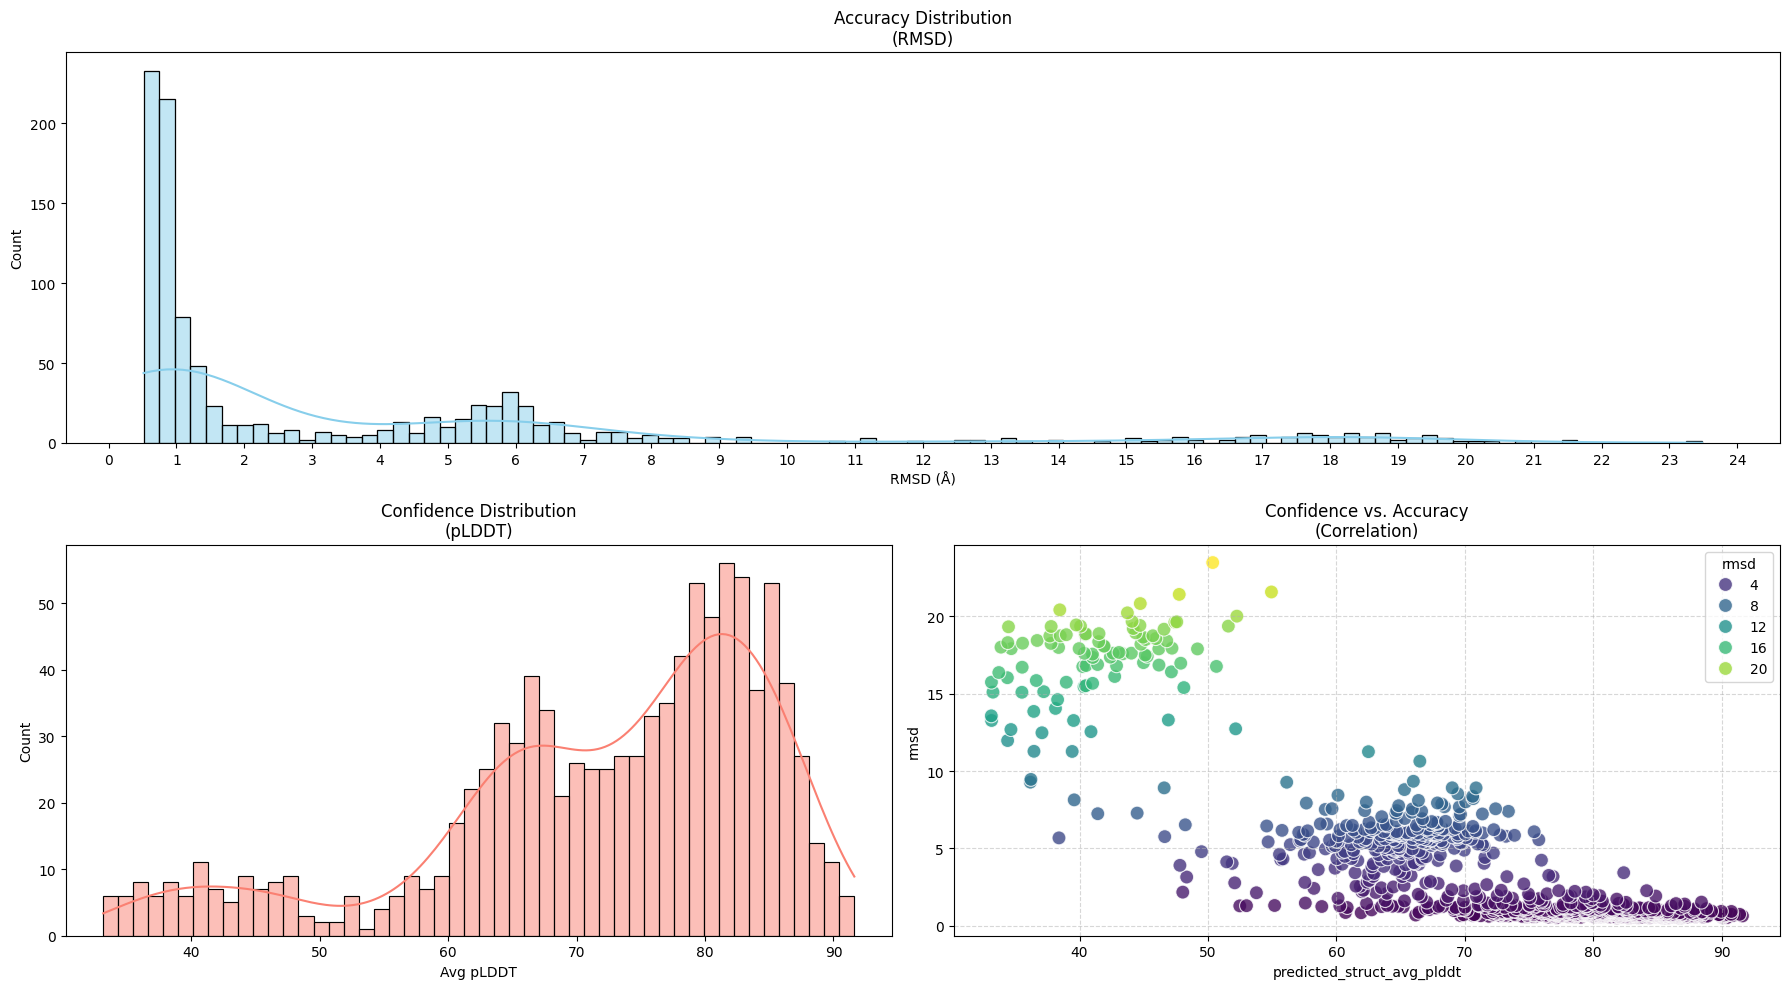

In [29]:
print("\n" + "="*40)
print("STATISTICAL SUMMARY")
print("="*40)

print(f"Total Predictions: {len(results_df)}")


# Accuracy stats
print(f"\n[Accuracy (RMSD)]")
print(f"  Best (Lowest):   {results_df.iloc[0]['name']} ({results_df.iloc[0]['rmsd']:.3f} Å)")
print(f"  Mean RMSD:       {results_df['rmsd'].mean():.3f} Å")

# Confidence stats
print(f"\n[Confidence (pLDDT)]")
best_plddt_row = results_df.loc[results_df['predicted_struct_avg_plddt'].idxmax()]
print(f"  Highest pLDDT:   {best_plddt_row['name']} ({best_plddt_row['predicted_struct_avg_plddt']:.2f})")
print(f"  Mean pLDDT:      {results_df['predicted_struct_avg_plddt'].mean():.2f}")

# pearsonr returns (correlation_coefficient, p_value)
corr_coeff, p_value = pearsonr(results_df['predicted_struct_avg_plddt'], results_df['rmsd'])
print(f"  Pearson R:       {corr_coeff:.3f}")
print(f"  P-value:         {p_value:.3e} " + ("(Significant)" if p_value < 0.05 else "(Not Significant)"))

# 3. Visualization
plt.figure(figsize=(18, 10))

# Plot 1: RMSD Distribution
plt.subplot(2, 2, (1, 2))
sns.histplot(results_df['rmsd'], kde=True, color='skyblue', bins=100)
plt.title('Accuracy Distribution\n(RMSD)')
plt.xlabel('RMSD (Å)')
plt.locator_params(axis='x', nbins=50)


# Plot 2: pLDDT Distribution
plt.subplot(2, 2, 3)
sns.histplot(results_df['predicted_struct_avg_plddt'], kde=True, color='salmon', bins=50)
plt.title('Confidence Distribution\n(pLDDT)')
plt.xlabel('Avg pLDDT')

# Plot 3: Correlation (Guaranteed Aligned)
plt.subplot(2, 2, 4)
# We use results_df as the source, ensuring X and Y are paired by index
sns.scatterplot(data=results_df, x='predicted_struct_avg_plddt', y='rmsd', 
                hue='rmsd', palette='viridis', s=100, alpha=0.8)
plt.title('Confidence vs. Accuracy\n(Correlation)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
# well folded threholds
# 1. Define your thresholds
plddt_cutoff = 70
rmsd_cutoff = 4.0

# 2. Create a 'quality' label for easy visualization later
results_df['fold_success'] = (results_df['predicted_struct_avg_plddt'] > plddt_cutoff) & \
                        (results_df['rmsd'] < rmsd_cutoff)

# 3. Create a subset of just the "Good" structures
good_structures_df = results_df[results_df['fold_success']].copy()

# 4. Display the results
print(f"Total Models: {len(results_df)}")
print(f"Good Models Found: {len(good_structures_df)}")

if not good_structures_df.empty:
    print("\n--- Top 'Good' Structures ---")
    print(good_structures_df[['name', 'rmsd', 'predicted_struct_avg_plddt']].head())
else:
    print("\nNo structures met both the pLDDT and RMSD criteria.")

Total Models: 1001
Good Models Found: 590

--- Top 'Good' Structures ---
                                                name      rmsd  \
0  T=0.2_sample=431_score=0.5895_global_score=0.5...  0.516130   
1  T=0.2_sample=22_score=0.5073_global_score=0.50...  0.519586   
2  T=0.2_sample=415_score=0.5438_global_score=0.5...  0.524052   
3  T=0.2_sample=285_score=0.5488_global_score=0.5...  0.529734   
4  T=0.2_sample=101_score=0.5297_global_score=0.5...  0.536658   

   predicted_struct_avg_plddt  
0                   86.824868  
1                   85.536184  
2                   81.844079  
3                   82.828202  
4                   77.160263  
